# The pairwise scenario

Two aircraft start on a collision course. Each aircraft runs the full stack against the other one,
and the run continues to the end of the encounter. This is the building block. The ring and the
random traffic scale from it, and each of them reduces to it at two aircraft.

`create_conflict` places the intruder at a chosen crossing angle, so the pair reaches a chosen
miss distance at a chosen time. This notebook uses `dcpa = 0`, which is the worst case, and it
sweeps the
crossing angle.

The pairwise scenario has one property the other scenarios do not have. **The three metrics are one
number.** One loss involves two aircraft, and one run has two aircraft, so the per-aircraft and the
per-run probabilities are equal. There is also one pair only, so the mean number of losing pairs
cannot be more than 1. Thus a pairwise result needs no conversion before a comparison with the
literature.

In [1]:
%matplotlib inline
import dataclasses
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed

plt.rcParams["figure.dpi"] = 130

from opencdarr import GnssNavigation, M600, MVP, PastCPA, StateBased, geo
from opencdarr.config import load_config
from opencdarr.estimator import agents_for, combine_ipr, estimate_ipr_over
from opencdarr.fleet import run_fleet
from opencdarr.rng import children, generator, root_seed_sequence, spawn
from opencdarr.scenario import PairwiseEncounter

BLUE, RED, ORANGE, GREY = "#1f77b4", "#d62728", "#ff7f0e", "0.45"
JOBS = 8
SEED = 20260805
POS_CI95 = 10.0

BASE = load_config("../../configs/pairwise.yaml")
RPZ = BASE.conflict.rpz

SITE_IMG = Path.home() / "Projects/opencdarr.github.io/docs/assets/img"


def publish(fig, name: str) -> None:
    if SITE_IMG.is_dir():
        fig.savefig(SITE_IMG / f"{name}.png", dpi=130)


def config(pos_ci95: float, n_encounters: int):
    return dataclasses.replace(
        BASE, seed=SEED, n_encounters=n_encounters,
        scenario=dataclasses.replace(BASE.scenario, speed=10.0, tlos=180.0,
                                     pos_ci95=pos_ci95, vel_ci95=pos_ci95 / 10.0),
    )


print(f"rpz {RPZ:.0f} m   lookahead {BASE.conflict.t_lookahead:.0f} s   "
      f"tlos {BASE.scenario.tlos:.0f} s   pos_ci95 {POS_CI95:.0f} m")

rpz 50 m   lookahead 120 s   tlos 60 s   pos_ci95 10 m


## Part 1 — what one hundred encounters look like

The figure shows the ground tracks of 100 encounters at three crossing angles. The geometry is
the same in each encounter of a column. Only the GNSS noise changes, so the spread between the
tracks is
the effect of that noise on the resolution.

The bottom row is the closest approach. Each point is one encounter. A point inside the red circle
is a loss of separation.

In [2]:
ANGLES = [2.0, 45.0, 135.0]
N_SHOW = 100


def fly_one(seq, dpsi: float, pos_ci95: float):
    cfg = config(pos_ci95, 1)
    sc = PairwiseEncounter(dpsi=dpsi, dcpa=0.0)
    fleet = sc.draw(generator(seq), cfg)
    nav, _, _ = spawn(seq, 3)
    return run_fleet(
        agents_for(fleet, M600), rpz=cfg.conflict.rpz,
        t_lookahead=cfg.conflict.t_lookahead, dt=cfg.simulation.dt,
        detector=StateBased(), resolver=MVP(1.05), recovery=PastCPA(),
        navigation=GnssNavigation(), rng=generator(nav), t_max=cfg.simulation.t_max,
        done_timeout=cfg.simulation.done_timeout, record=True)


shown = {}
for dpsi in ANGLES:
    t0 = time.perf_counter()
    shown[dpsi] = [fly_one(s, dpsi, POS_CI95)
                   for s in spawn(root_seed_sequence(SEED), N_SHOW)]
    outs = shown[dpsi]
    print(f"dpsi {dpsi:5.1f} deg   losses {sum(o.los for o in outs):>3}/{N_SHOW}   "
          f"closest approach overall {min(o.min_sep for o in outs):6.1f} m   "
          f"{time.perf_counter() - t0:5.1f} s")

dpsi   2.0 deg   losses   7/100   closest approach overall   47.9 m     2.1 s


dpsi  45.0 deg   losses   0/100   closest approach overall   67.9 m     1.4 s


dpsi 135.0 deg   losses   0/100   closest approach overall   59.7 m     1.5 s


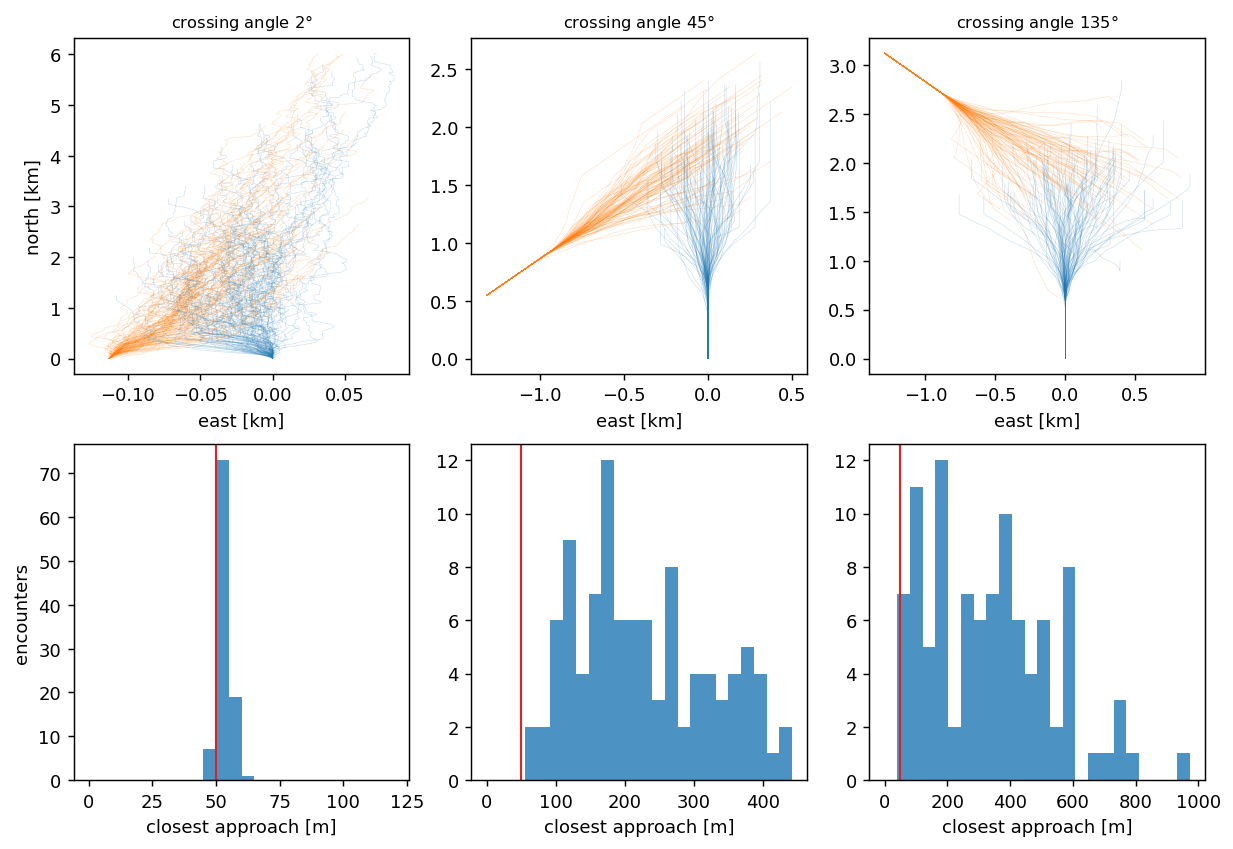

In [3]:
def tracks_enu(outcome):
    frames = outcome.frames
    lat0, lon0 = frames[0].states[0].lat, frames[0].states[0].lon
    out = []
    for i in range(len(frames[0].states)):
        xy = []
        for f in frames:
            qdr, dist = geo.qdrdist(lat0, lon0, f.states[i].lat, f.states[i].lon)
            a = np.radians(qdr)
            xy.append((dist * np.sin(a), dist * np.cos(a)))
        out.append(np.array(xy))
    return out


fig, axes = plt.subplots(2, len(ANGLES), figsize=(9.6, 6.6))

for col, dpsi in enumerate(ANGLES):
    ax = axes[0, col]
    for outcome in shown[dpsi]:
        for k, track in enumerate(tracks_enu(outcome)):
            ax.plot(track[:, 0] / 1000, track[:, 1] / 1000,
                    color=BLUE if k == 0 else ORANGE, lw=0.3, alpha=0.25)
    ax.set_title(f"crossing angle {dpsi:.0f}$\\degree$", fontsize=9)
    ax.set_xlabel("east [km]")
    if col == 0:
        ax.set_ylabel("north [km]")
    ax.set_box_aspect(1)

    ax = axes[1, col]
    seps = np.array([o.min_sep for o in shown[dpsi]])
    ax.hist(seps, bins=np.linspace(0, max(120.0, seps.max()), 25), color=BLUE, alpha=0.8)
    ax.axvline(RPZ, color=RED, lw=1.2)
    ax.set_xlabel("closest approach [m]")
    if col == 0:
        ax.set_ylabel("encounters")
    ax.set_box_aspect(1)

fig.tight_layout()
publish(fig, "scenario-pairwise-tracks")

## Part 2 — the three metrics are one number

The sweep runs the crossing angle at one accuracy. Each cell reports the three quantities. They
must be equal on every row. A difference between them is an error in the counting, not a
property of the
scenario.

In [4]:
SWEEP_ANGLES = [2.0, 15.0, 45.0, 90.0, 135.0, 175.0]
N_ENC = 4_000


def run_mc(dpsi: float, pos_ci95: float, n_encounters: int):
    cfg = config(pos_ci95, n_encounters)
    sc = PairwiseEncounter(dpsi=dpsi, dcpa=0.0)
    root = root_seed_sequence(cfg.seed)
    bounds = [(i * n_encounters // JOBS, (i + 1) * n_encounters // JOBS) for i in range(JOBS)]
    parts = Parallel(n_jobs=JOBS)(
        delayed(estimate_ipr_over)(sc, cfg, M600, StateBased(), MVP(1.05), PastCPA(),
                                   GnssNavigation(), seqs=children(root, lo, hi))
        for lo, hi in bounds)
    return combine_ipr(parts)


sweep = {}
print(f"{'dpsi':>7}{'P_ac':>10}{'P_run':>10}{'E[K]':>10}{'equal':>8}"
      f"{'median min_sep':>17}")
for dpsi in SWEEP_ANGLES:
    r = run_mc(dpsi, POS_CI95, N_ENC)
    sweep[dpsi] = r
    equal = (abs(r.p_ac - r.p_los) < 1e-12) and (abs(r.mean_los_pairs - r.p_los) < 1e-12)
    print(f"{dpsi:7.1f}{r.p_ac:10.4f}{r.p_los:10.4f}{r.mean_los_pairs:10.4f}"
          f"{'yes' if equal else 'NO':>8}{r.median_min_sep:17.1f}")

   dpsi      P_ac     P_run      E[K]   equal   median min_sep


    2.0    0.0445    0.0445    0.0445     yes             53.3


   15.0    0.0008    0.0008    0.0008     yes            110.2


   45.0    0.0003    0.0003    0.0003     yes            209.6


   90.0    0.0000    0.0000    0.0000     yes            288.2


  135.0    0.0000    0.0000    0.0000     yes            323.4


  175.0    0.0000    0.0000    0.0000     yes            315.6


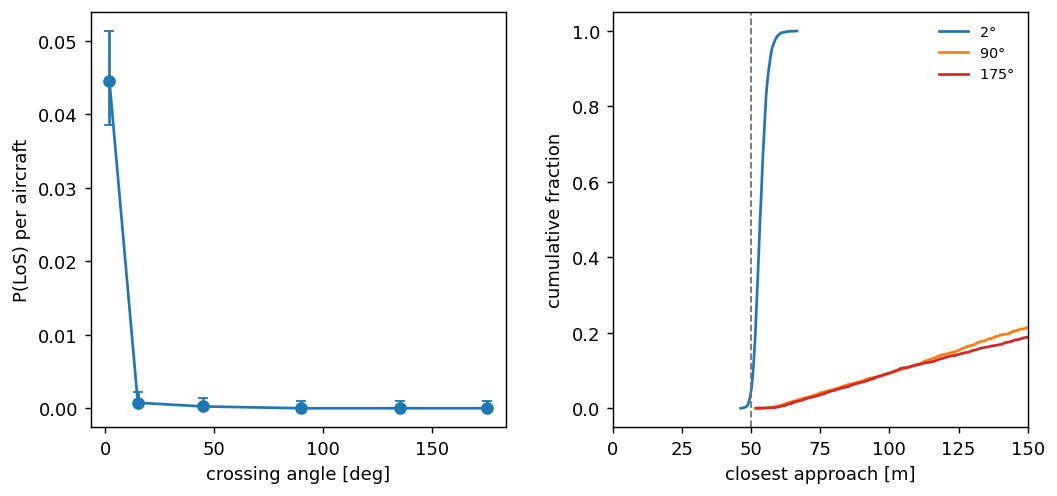

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.9))

ax = axes[0]
xs = SWEEP_ANGLES
ps = [sweep[a].p_ac for a in xs]
lo = [sweep[a].p_ac - sweep[a].ci95[0] for a in xs]
hi = [sweep[a].ci95[1] - sweep[a].p_ac for a in xs]
ax.errorbar(xs, ps, yerr=[lo, hi], fmt="o-", color=BLUE, capsize=3)
ax.set_xlabel("crossing angle [deg]"); ax.set_ylabel("P(LoS) per aircraft")
ax.set_box_aspect(1)

ax = axes[1]
picked = [SWEEP_ANGLES[0], SWEEP_ANGLES[len(SWEEP_ANGLES) // 2], SWEEP_ANGLES[-1]]
for dpsi, colour in zip(picked, [BLUE, ORANGE, RED]):
    seps = np.sort(np.array(sweep[dpsi].min_seps))
    ax.plot(seps, np.arange(1, len(seps) + 1) / len(seps), color=colour,
            label=f"{dpsi:.0f}$\\degree$")
ax.axvline(RPZ, color=GREY, lw=1.0, ls="--")
ax.set_xlim(0, 150); ax.set_xlabel("closest approach [m]")
ax.set_ylabel("cumulative fraction"); ax.set_box_aspect(1)
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
publish(fig, "scenario-pairwise-metrics")

## What this shows

The pairwise scenario is the reference. Its three metrics are equal on every cell of the sweep,
so a
pairwise number is directly comparable with the per-aircraft numbers in the literature.

The crossing angle changes the difficulty. A near head-on geometry gives the relative velocity
the largest magnitude and the resolution the least time, so it gives the largest probability.

The rare-event validation notebook uses this same scenario to compare the two estimators.